C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

Model and Data Loaded.
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Generated 3461 synthetic sequences.


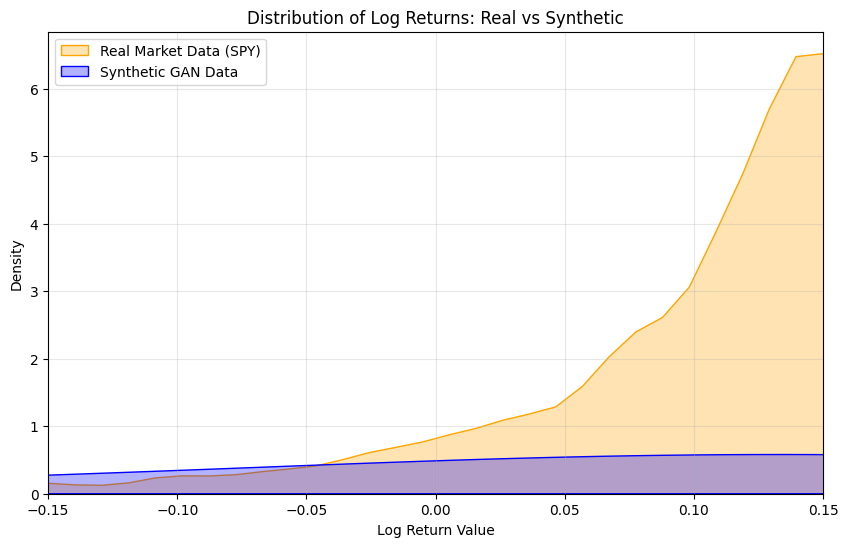

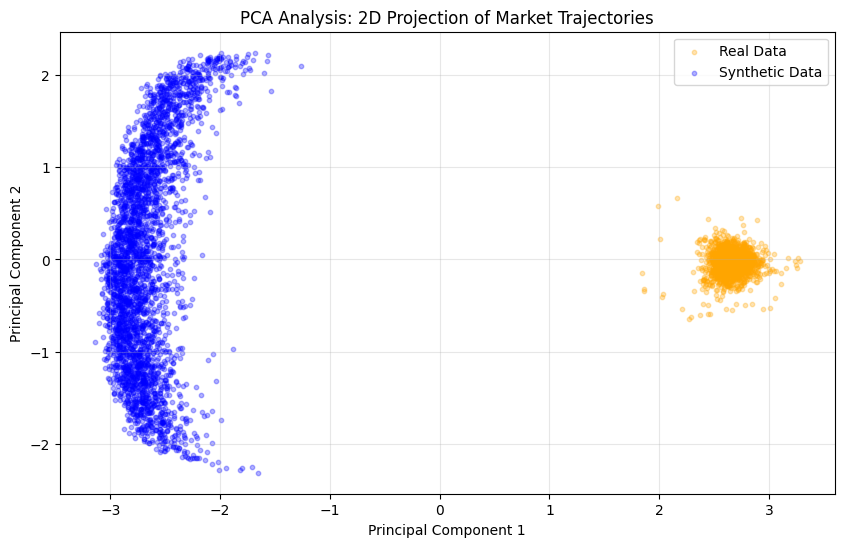

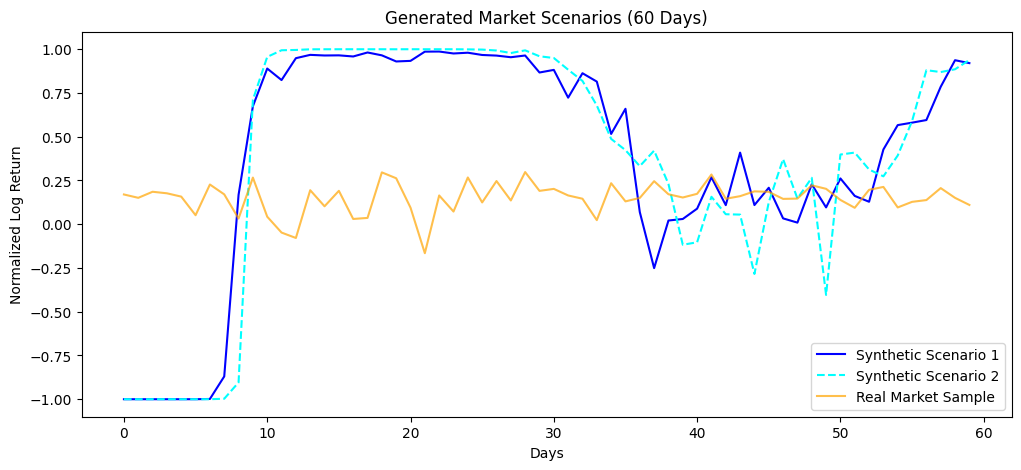

Step 4 Complete: Final graphs generated.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os

# --- Configuration ---
BASE_PATH = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_PATH, 'data')
MODEL_PATH = os.path.join(BASE_PATH, 'models')
IMAGE_PATH = os.path.join(BASE_PATH, 'images')

# Load Data and Model
X_train = np.load(os.path.join(DATA_PATH, 'training_data.npy'))
# Load the IMPROVED generator
generator = load_model(os.path.join(MODEL_PATH, 'generator_improved.h5'))

print("Model and Data Loaded.")

# --- 1. Generate Synthetic Data ---
# We generate the same amount of data as we have real samples to make a fair comparison
latent_dim = 100
noise = np.random.normal(0, 1, (X_train.shape[0], latent_dim))
generated_data = generator.predict(noise)

print(f"Generated {generated_data.shape[0]} synthetic sequences.")

# --- 2. Statistical Visualization: Distribution of Returns ---
# We flatten the data to compare the overall distribution of values
real_flat = X_train.flatten()
fake_flat = generated_data.flatten()

plt.figure(figsize=(10, 6))
sns.kdeplot(real_flat, label='Real Market Data (SPY)', fill=True, color='orange', alpha=0.3)
sns.kdeplot(fake_flat, label='Synthetic GAN Data', fill=True, color='blue', alpha=0.3)
plt.title('Distribution of Log Returns: Real vs Synthetic')
plt.xlabel('Log Return Value')
plt.ylabel('Density')
plt.legend()
plt.xlim(-0.15, 0.15) # Zoom in to the center
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(IMAGE_PATH, 'final_distribution_compare.png'))
plt.show()

# --- 3. PCA Visualization (2D Projection) ---
# We want to see if the "shape" of the sequences overlaps
# PCA reduces the 60-day sequence into 2 points (x, y)

# Reshape for PCA: (Samples, 60)
real_pca_input = X_train.reshape(X_train.shape[0], 60)
fake_pca_input = generated_data.reshape(generated_data.shape[0], 60)

# Combine for PCA training
combined_data = np.vstack((real_pca_input, fake_pca_input))
labels = np.hstack((np.ones(len(real_pca_input)), np.zeros(len(fake_pca_input))))

pca = PCA(n_components=2)
pca_results = pca.fit_transform(combined_data)

# Split back
real_pca = pca_results[labels == 1]
fake_pca = pca_results[labels == 0]

plt.figure(figsize=(10, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.3, label='Real Data', color='orange', s=10)
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], alpha=0.3, label='Synthetic Data', color='blue', s=10)
plt.title('PCA Analysis: 2D Projection of Market Trajectories')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(IMAGE_PATH, 'final_pca_analysis.png'))
plt.show()

# --- 4. Single Trajectory Comparison ---
# Let's plot "One Good Example" for the report
plt.figure(figsize=(12, 5))
plt.plot(generated_data[10], label='Synthetic Scenario 1', color='blue')
plt.plot(generated_data[20], label='Synthetic Scenario 2', color='cyan', linestyle='--')
plt.plot(X_train[0], label='Real Market Sample', color='orange', alpha=0.7)
plt.title('Generated Market Scenarios (60 Days)')
plt.ylabel('Normalized Log Return')
plt.xlabel('Days')
plt.legend()
plt.savefig(os.path.join(IMAGE_PATH, 'final_scenarios.png'))
plt.show()

print("Step 4 Complete: Final graphs generated.")